In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [5]:
def f(x):
    return 3*x**2 - 4*x + 5

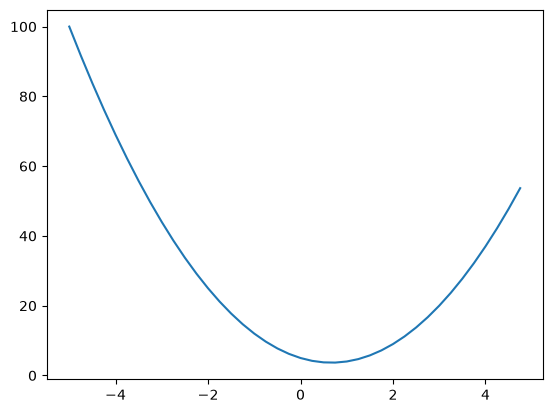

In [6]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [7]:
h = 0.0000001
x = -3.0
(f(x + h) - f(x))/h

-21.999999688659955

In [8]:
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1: ', d1)
print('d2: ', d2)
print('slope', (d2-d1)/h)

d1:  4.0
d2:  4.000000099999999
slope 0.999999993922529


In [148]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self.grad = 0.0
        self._backward = lambda: None
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)

        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [25]:
a = Value(2.0)
b = Value(3.0)
a / b

Value(data=0.6666666666666666)

In [149]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        # create square node to each variable
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')

        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [150]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label ='x1w1'
x2w2 = x2 * w2; x2w2.label ='x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'

n = x1w1x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'


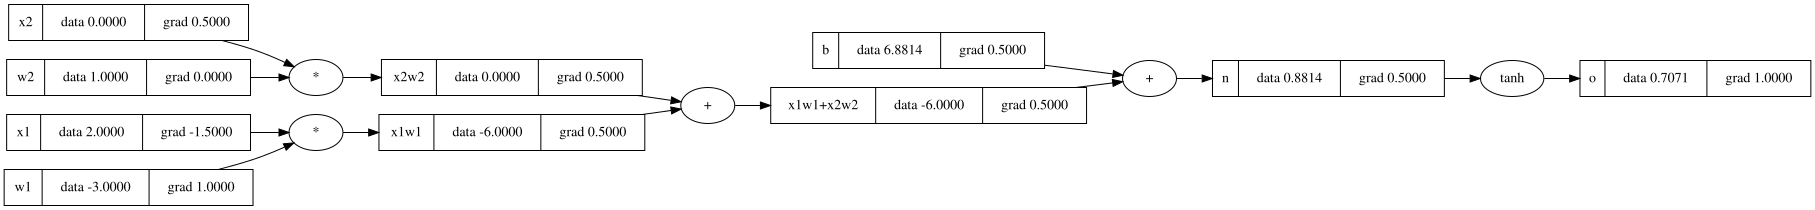

In [151]:
o.backward()
draw_dot(o)

In [152]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label ='x1w1'
x2w2 = x2 * w2; x2w2.label ='x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'

n = x1w1x2w2 + b; n.label='n'
# ----
e = (2*n).exp(); e.label='e'
o = (e - 1)/(e + 1); o.label='o'

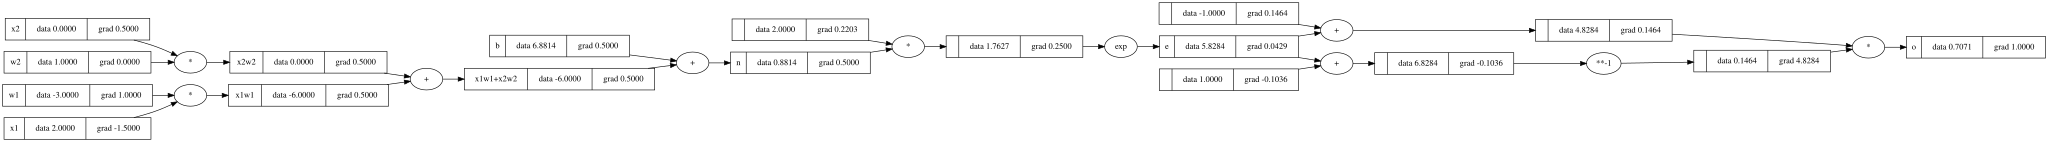

In [153]:
o.backward()
draw_dot(o)

In [48]:
import torch

In [154]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad=True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad=True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad=True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad=True
b  = torch.Tensor([6.8813735870195432]).double(); b.requires_grad=True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

0.7071066904050358


In [155]:
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [167]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        p = self.w + [self.b] 
        return p

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nout): # nin as starting point, nout as list of layer's length
        sz = [nin] + nout
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nout))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [179]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
len(n.parameters())

41

In [180]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [181]:
epoch = 10000
lr = 0.01

for k in range(epoch):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -lr * p.grad

    print(k, loss.data) 


0 7.866474726877539
1 6.900601462825996
2 6.23963147317452
3 5.76772836174102
4 5.399581086522879
5 5.092526164165998
6 4.827426118237823
7 4.5953459354011335
8 4.391126569322534
9 4.210798249153756
10 4.050787988841934
11 3.9078132100619336
12 3.7789462617449674
13 3.661666005595225
14 3.553861239416434
15 3.45379808757317
16 3.360069255453316
17 3.2715375510285183
18 3.1872803111970804
19 3.1065377283285724
20 3.0286662415545083
21 2.953097377993471
22 2.8793021129065837
23 2.806760630319631
24 2.7349371866931005
25 2.663259654149499
26 2.5911034143881104
27 2.5177798496960144
28 2.4425310603684873
29 2.3645349714248494
30 2.282928851289464
31 2.1968639094912517
32 2.1056065897552427
33 2.0086972852070684
34 1.9061547251512034
35 1.7986689505792168
36 1.6876774677119928
37 1.5752253125689255
38 1.4636160226113815
39 1.3550029942263073
40 1.251102618298627
41 1.15309904469747
42 1.0616879993332105
43 0.9771754238320258
44 0.8995783715343437
45 0.828710026011113
46 0.7642470255668621
4

In [182]:
ypred

[Value(data=0.9917023461882545),
 Value(data=-0.9897175625349789),
 Value(data=-0.9946303927059172),
 Value(data=0.9921123408887477)]

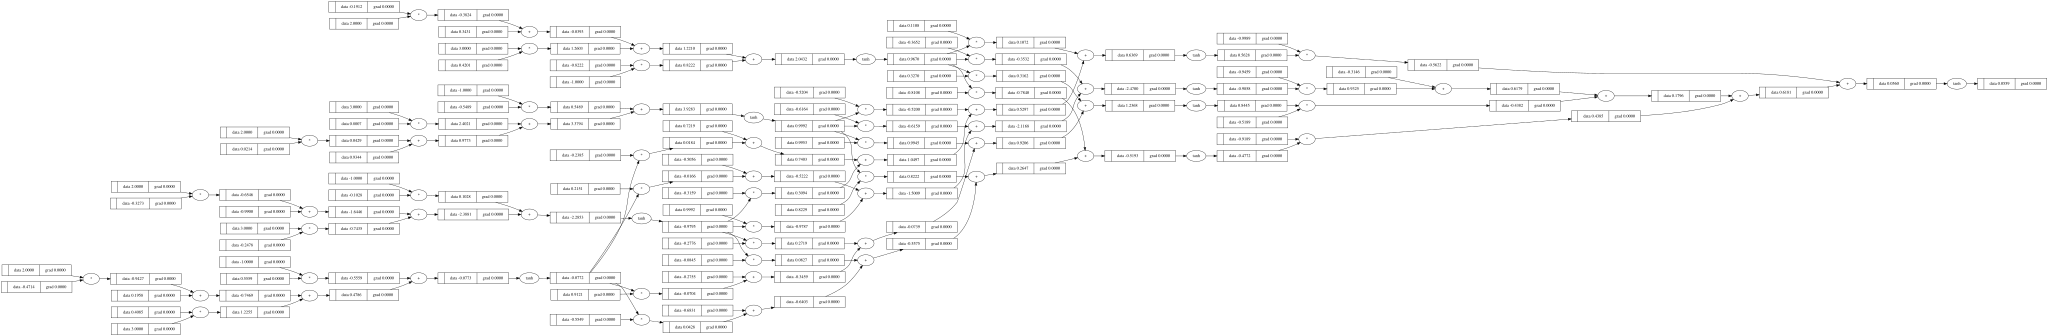

In [147]:
draw_dot(n(x))